From the [Muon Tutorials for Single-cell RNA-seq and ATAC-seq integration](https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/1-Gene-Expression-Processing.html)

In [2]:
# Single-cell packages
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import anndata as ad
import pysam

from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing

# Setting figure parameters
sc.settings.verbosity = 0

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")

tss_path = PROJECT_DIR / "data/genome_data/genome_annotation/hg38/gene_tss.bed"

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw" / "K562_10x_raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed" / "K562_muon_preprocessing"
SAMPLE_NAME = "sample_1"

# Set to None if you have 10X files instead of count files
rna_count_file = None
atac_count_file = None

# Set to None if you have matrix, features, barcode files instead of an h5 file
raw_h5_file = PROJECT_DIR / "data" / "raw" / "K562_10x_raw" / "GSM5396329_barnyard_raw_feature_bc_matrix.h5"

# If you want to keep all TFs to maximize overlap with the ground truth files, pass in a ground truth file path here.
tf_list_file = PROJECT_DIR / "data" / "ground_truth_files" / "chipatlas_K562.csv"

# If you are running with 10X, replace None with the path to your indexed fragment file (for nucleosome signal filtering)
frag_path = PROJECT_DIR / "data" / "raw" / "K562_10x_raw" / "fragments.tsv.gz"

SAMPLE_DATA_DIR = RAW_DATA_DIR / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = PROCESSED_DATA_DIR / SAMPLE_NAME

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

print(f"Loading data for sample {SAMPLE_NAME} from {RAW_DATA_DIR}...")
# print all files in the data directory
for file in SAMPLE_DATA_DIR.glob("*"):
    print(f"  - {file.name}")
    
filtering_setting_df = pd.read_csv(PROJECT_DIR / "dev" / "notebooks" / "muon_preprocessing" /"qc_filtering_settings.tsv", sep="\t")
sample_filtering_settings = filtering_setting_df[filtering_setting_df["Sample"] == SAMPLE_NAME]  

Loading data for sample sample_1 from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/K562_10x_raw...


In [3]:
def get_threshold(setting_name):
    setting_value = sample_filtering_settings[setting_name].values[0]
    print(f"{setting_name}: {setting_value}")
    
    return setting_value

# ----- RNA QC thresholds -----
MIN_CELLS_PER_GENE = get_threshold("Min Cells per Gene")

MIN_GENES_PER_CELL = get_threshold("Min Genes per Cell")
MAX_GENES_PER_CELL = get_threshold("Max Genes per Cell")

MIN_TOTAL_COUNTS = get_threshold("Min Total Counts")
MAX_TOTAL_COUNTS = get_threshold("Max Total Counts")
MAX_PCT_COUNTS_MT = get_threshold("Max Pct MT")

# ----- ATAC QC thresholds -----
MIN_CELLS_PER_PEAK = get_threshold("Min Cells per Peak")

MIN_PEAKS_PER_CELL = get_threshold("Min Peaks per Cell")
MAX_PEAKS_PER_CELL = get_threshold("Max Peaks per Cell")

MIN_TOTAL_PEAK_COUNTS = get_threshold("Min Total Peak Counts")
MAX_TOTAL_PEAK_COUNTS = get_threshold("Max Total Peak Counts")

Min Cells per Gene: 3
Min Genes per Cell: 1000
Max Genes per Cell: 10000
Min Total Counts: 500
Max Total Counts: 50000
Max Pct MT: 20
Min Cells per Peak: 1
Min Peaks per Cell: 100
Max Peaks per Cell: 20000
Min Total Peak Counts: 1000
Max Total Peak Counts: 50000


## Load in the Raw Data

In [4]:
def normalize_peak_format(peak_id: str) -> str:
    """
    Normalize peak format from chrN-start-end or chrN:start:end to chrN:start-end.
    Handles both formats as input and always outputs chrN:start-end.
    """
    if not isinstance(peak_id, str):
        return peak_id
    
    # Try to parse chr-start-end format (with dashes)
    parts = peak_id.split('-')
    if len(parts) >= 3:
        # Assume format is chr-start-end where chr might have dashes
        # Work backwards: the last two parts are start and end
        try:
            end = int(parts[-1])
            start = int(parts[-2])
            chrom = '-'.join(parts[:-2])  # Everything before the last two parts
            return f"{chrom}:{start}-{end}"
        except (ValueError, IndexError):
            pass
    
    # Already in chr:start-end format or some other format, return as-is
    return peak_id

def construct_from_gene_by_cell_matrices(rna_count_file, atac_count_file):
    assert rna_count_file.exists(), "rna count file does not exist"
    assert atac_count_file.exists(), "atac count file does not exist"
    
    rna_count_matrix = pd.read_csv(rna_count_file, header=0, index_col=0)
    atac_count_matrix = pd.read_csv(atac_count_file, header=0, index_col=0)
    
    rna_matrix = rna_count_matrix.T.values
    rna_metadata_df = pd.DataFrame(index=rna_count_matrix.columns)
    rna_features_df = pd.DataFrame(index=rna_count_matrix.index)
    
    atac_count_matrix.index = atac_count_matrix.index.map(normalize_peak_format)

    atac_matrix = atac_count_matrix.T.values
    atac_metadata_df = pd.DataFrame(index=atac_count_matrix.columns)
    atac_features_df = pd.DataFrame(index=atac_count_matrix.index)
    
    adata_rna = ad.AnnData(X=rna_matrix, obs=rna_metadata_df, var=rna_features_df)
    adata_rna.var["feature_types"] = "Gene Expression"
    adata_rna.var["gene_ids"] = adata_rna.var_names

    adata_atac = ad.AnnData(X=atac_matrix, obs=atac_metadata_df, var=atac_features_df)
    adata_atac.var["feature_types"] = "Peaks"
    adata_atac.var["gene_ids"] = adata_atac.var_names

    mdata = mu.MuData({'rna': adata_rna, 'atac': adata_atac})

    return mdata

def filter_to_human(mdata):
    """
    Filter a barnyard MuData object to hg38 ATAC peaks only,
    then strip the 'hg38.' prefix from peak IDs.
    """
    # annotate species from interval
    mdata["atac"].var["species"] = (
        mdata["atac"].var["interval"].str.split(".", n=1).str[0]
    )

    # keep only hg38 peaks
    hg38_mask = mdata["atac"].var["species"] == "hg38"
    mdata.mod["atac"] = mdata["atac"][:, hg38_mask].copy()

    # strip prefix from identifiers
    mdata.mod["atac"].var_names = (
        mdata.mod["atac"].var_names.str.replace(r"^hg38\.", "", regex=True)
    )
    mdata.mod["atac"].var["gene_ids"] = (
        mdata.mod["atac"].var["gene_ids"].str.replace(r"^hg38\.", "", regex=True)
    )
    mdata.mod["atac"].var["interval"] = (
        mdata.mod["atac"].var["interval"].str.replace(r"^hg38\.", "", regex=True)
    )
    mdata = mu.MuData(mdata.mod)

    return mdata

Build the mdata object, either from raw 10X genomic data, a 10x h5 file, or from a counts file. If you build from counts files, you won't be able to run the ATAC-seq QC filtering steps that require fragment files.

In [5]:
if rna_count_file is not None and atac_count_file is not None:
    rna_count_filepath = SAMPLE_DATA_DIR / rna_count_file
    atac_count_filepath = SAMPLE_DATA_DIR / atac_count_file
    
    mdata = construct_from_gene_by_cell_matrices(rna_count_filepath, atac_count_filepath)
    print("Constructed MuData object from count files.")
elif raw_h5_file is not None:
    mdata = mu.read_10x_h5(raw_h5_file)
else:
    mdata = mu.read_10x_mtx(SAMPLE_DATA_DIR)
        
if any(mdata.var["interval"].str.startswith("hg38.")):
    mdata = filter_to_human(mdata)

mdata.var_names_make_unique()
display(mdata)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/K562_10x_raw/GSM5396329_barnyard_raw_feature_bc_matrix.h5


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/sit

MuData object with n_obs × n_vars = 736320 × 246325
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	736320 x 68886
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	736320 x 177439
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'species'

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [6]:
print(mdata["rna"].var["gene_ids"][:5])
print(mdata["atac"].var["gene_ids"][:5])
print(mdata["rna"].var["feature_types"][:5])
print(mdata["atac"].var["feature_types"][:5])
print(mdata["rna"].X[:5, :5])

MIR1302-2HG    ENSG00000243485
FAM138A        ENSG00000237613
OR4F5          ENSG00000186092
AL627309.1     ENSG00000238009
AL627309.3     ENSG00000239945
Name: gene_ids, dtype: object
chr1:115460-115953    chr1:115460-115953
chr1:605411-605458    chr1:605411-605458
chr1:629038-635087    chr1:629038-635087
chr1:778232-779279    chr1:778232-779279
chr1:779839-779846    chr1:779839-779846
Name: gene_ids, dtype: object
MIR1302-2HG    Gene Expression
FAM138A        Gene Expression
OR4F5          Gene Expression
AL627309.1     Gene Expression
AL627309.3     Gene Expression
Name: feature_types, dtype: category
Categories (1, object): ['Gene Expression']
chr1:115460-115953    Peaks
chr1:605411-605458    Peaks
chr1:629038-635087    Peaks
chr1:778232-779279    Peaks
chr1:779839-779846    Peaks
Name: feature_types, dtype: category
Categories (1, object): ['Peaks']
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>


# RNA

In [7]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 736320 × 68886
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## Preprocessing

### QC

Some ground truth files have a very limited number of TFs.

In [8]:
def flag_tfs_to_keep(rna, tf_list_file):
    """
    Flags TF genes to keep based on a provided list of TFs. If the list is not provided or the file does not exist, flags all genes as False.
    """
    rna.var['keep_tf'] = False
    
    if tf_list_file is not None and tf_list_file.exists():
        tf_list_df = pd.read_csv(tf_list_file)

        tf_genes_to_keep = set(
            tf_list_df["source_id"].astype(str).str.strip().str.upper()
        )

        rna.var["keep_tf"] = (
            rna.var_names.astype(str).str.strip().str.upper().isin(tf_genes_to_keep)
        )
        

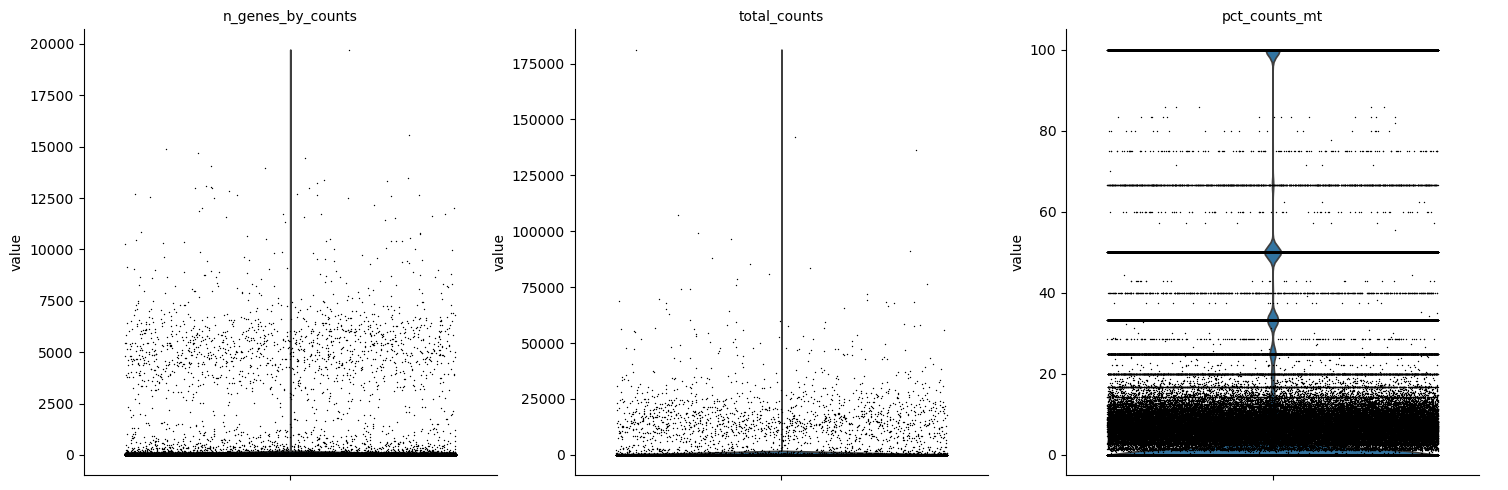

In [9]:
rna.var['mt'] = rna.var_names.str.upper().str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

Filter genes and cells based on the thresholds above

In [10]:
flag_tfs_to_keep(rna, tf_list_file)

tf_before = rna.var_names[rna.var["keep_tf"]]
print("TFs flagged before filtering:", len(tf_before))

mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: (x >= MIN_CELLS_PER_GENE) | rna.var['keep_tf'].to_numpy(dtype=bool))
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= MIN_GENES_PER_CELL) & (x <= MAX_GENES_PER_CELL))
mu.pp.filter_obs(rna, 'total_counts', lambda x: (x >= MIN_TOTAL_COUNTS) & (x <= MAX_TOTAL_COUNTS))
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x <= MAX_PCT_COUNTS_MT)

print("TFs remaining after filter:", rna.var["keep_tf"].sum())

missing_tfs = set(tf_before) - set(rna.var_names)
print("Missing TFs after filter:", len(missing_tfs))

TFs flagged before filtering: 1021
TFs remaining after filter: 1021
Missing TFs after filter: 0


Check to see how the data looks after filtering.

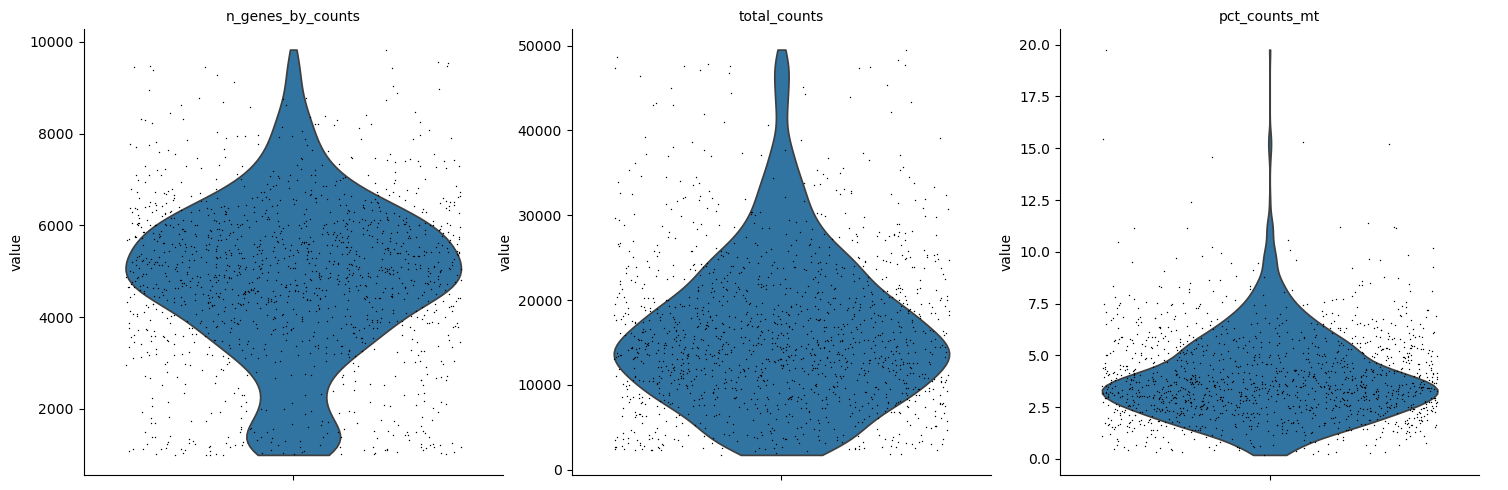

In [11]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [12]:
rna.layers["counts"] = rna.X.copy()

### Normalization

In [13]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

### Feature Selection

We will label highly variable genes that we'll use for downstream analysis.

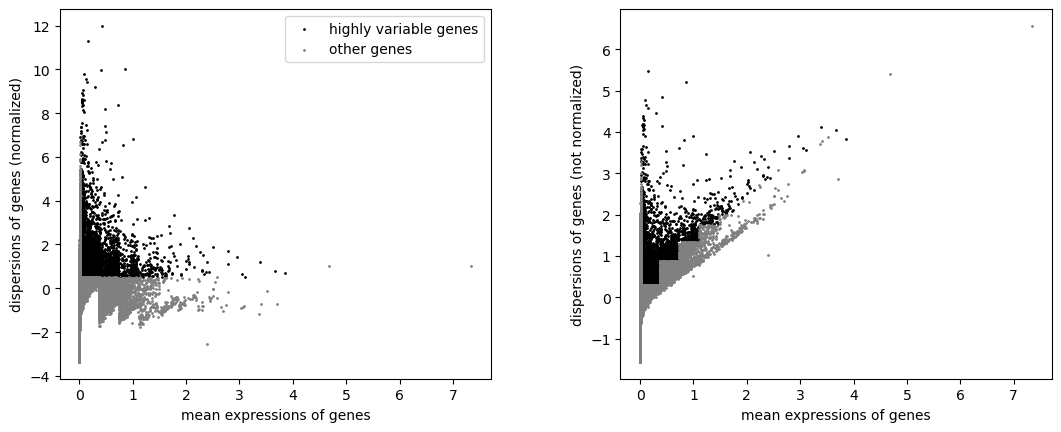

In [14]:
MIN_RNA_DISP = 0.5
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=MIN_RNA_DISP)
sc.pl.highly_variable_genes(rna)

Subset the RNA to only keep the highly variable genes and selected TFs

In [15]:
# keep_genes = rna.var["highly_variable"] | rna.var["keep_tf"]
# rna = rna[:, keep_genes]

In [16]:
np.sum(rna.var.highly_variable)

np.int64(7323)

### Scaling

We'll save log-normalized counts in a `.raw` slot:

In [17]:
rna.raw = rna

... and scale the log-normalized counts to zero mean and unit variance

In [18]:
sc.pp.scale(rna, max_value=10)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Analysis

### PCA and Neighborhood Graph

We will visualize some genes that we expect to see in the mESC cells.

['NOC2L', 'HES4', 'C1orf159']


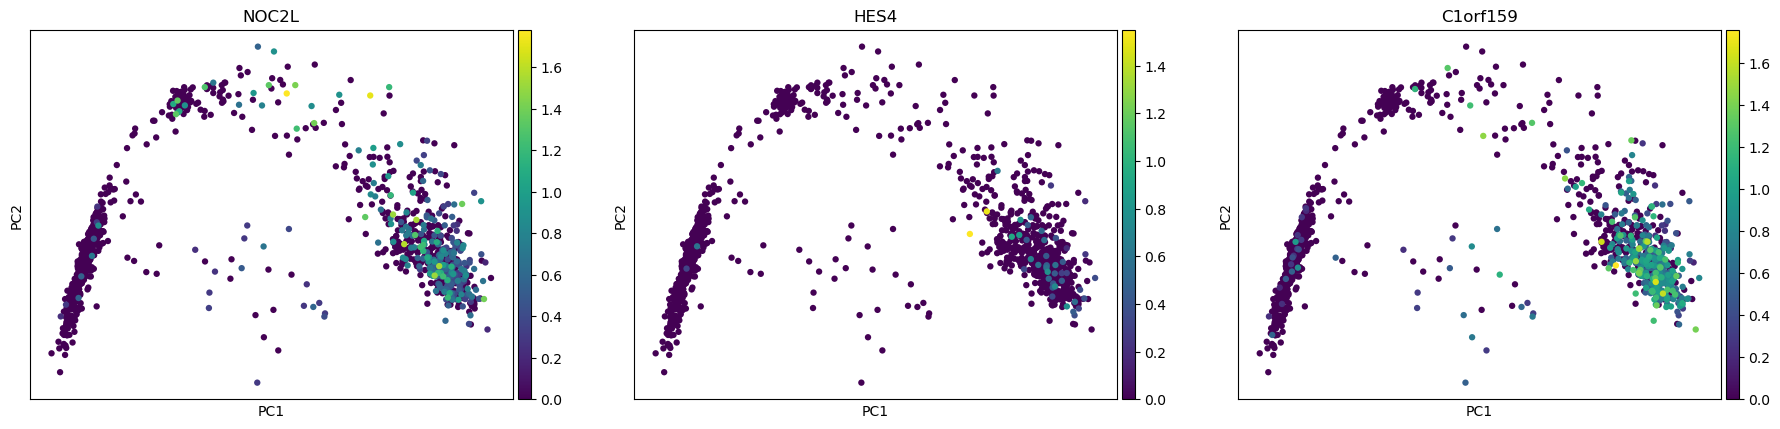

In [19]:
sc.tl.pca(rna, svd_solver='arpack')

first_three_hvg_genes = rna.var[rna.var.highly_variable].index[:3].to_list()
print(first_three_hvg_genes)

sc.pl.pca(rna, color=first_three_hvg_genes)

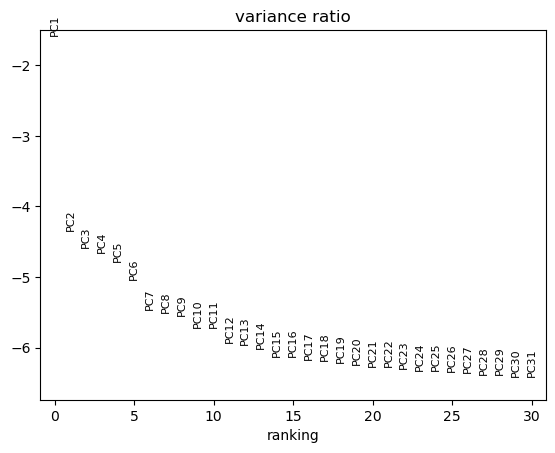

In [20]:
sc.pl.pca_variance_ratio(rna, log=True)

### Neighbors

In [21]:
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

### Non-linear dimensionality reduction and clustering

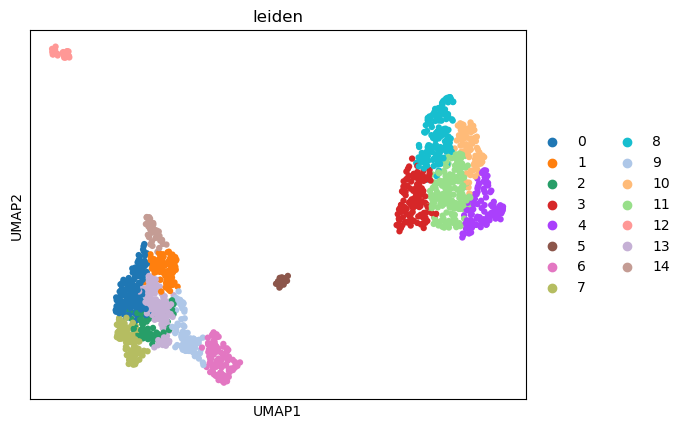

In [22]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(rna, flavor="igraph", n_iterations=2)
sc.pl.umap(rna, color=["leiden"])

## Saving progress to disk

In [23]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/rna"), rna)

---

# ATAC

In [24]:
atac = mdata.mod['atac']
atac  # an AnnData object

AnnData object with n_obs × n_vars = 736320 × 177439
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'species'

## Preprocessing

### QC

Filter out cells with too few peaks and peaks detected in too few cells.

In [25]:
def plot_cells_by_counts_violin(atac):
    plt.figure(figsize=(4, 4))
    sns.violinplot(y=atac.var["n_cells_by_counts"])
    random_sample_n = min(10000, atac.var["n_cells_by_counts"].shape[0])
    sample = atac.var["n_cells_by_counts"].sample(random_sample_n, random_state=11)
    plt.scatter(x=np.random.normal(0, 0.15, size=sample.shape[0]), y=sample, alpha=0.6, s=0.1, color="grey")
    plt.ylabel("Number of cells per peak")
    plt.title("n_cells_by_counts")
    plt.show()

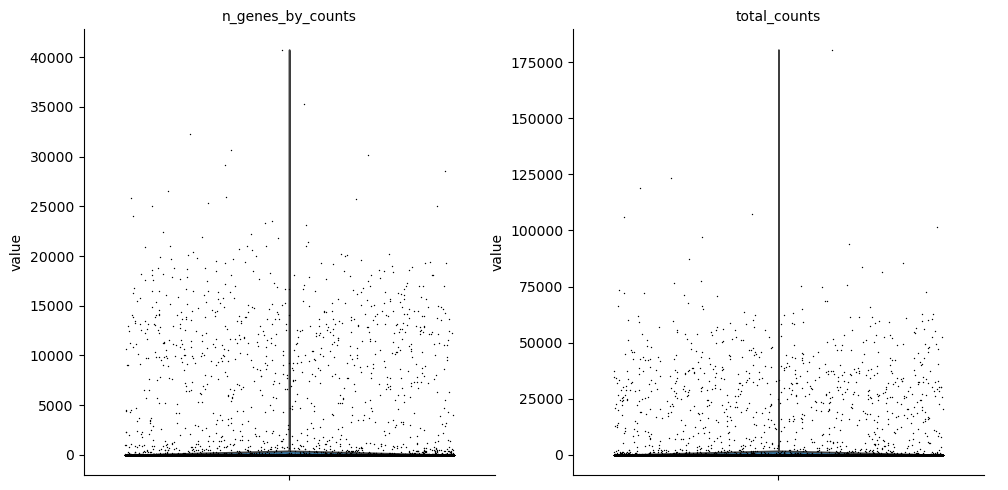

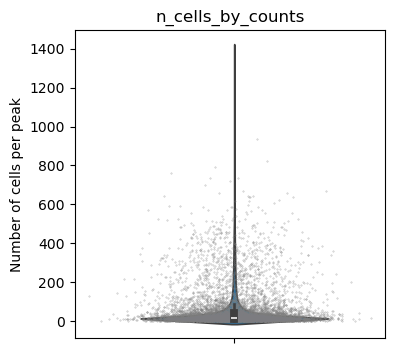

In [26]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)
plot_cells_by_counts_violin(atac)

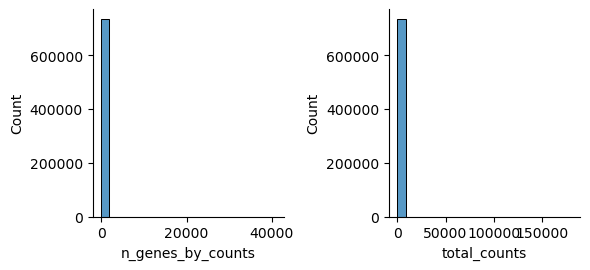

In [27]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])

In [28]:
# Remove peaks that are not detected in at least MIN_CELLS_PER_PEAK cells
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= MIN_CELLS_PER_PEAK)

# Remove cells where the number of accessible peaks is outside of the range [MIN_PEAKS_PER_CELL, MAX_PEAKS_PER_CELL]
mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= MIN_PEAKS_PER_CELL) & (x <= MAX_PEAKS_PER_CELL))

# Remove cells whose peak count sum is outside of the range [MIN_TOTAL_PEAK_COUNTS, MAX_TOTAL_PEAK_COUNTS]
mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= MIN_TOTAL_PEAK_COUNTS) & (x <= MAX_TOTAL_PEAK_COUNTS))

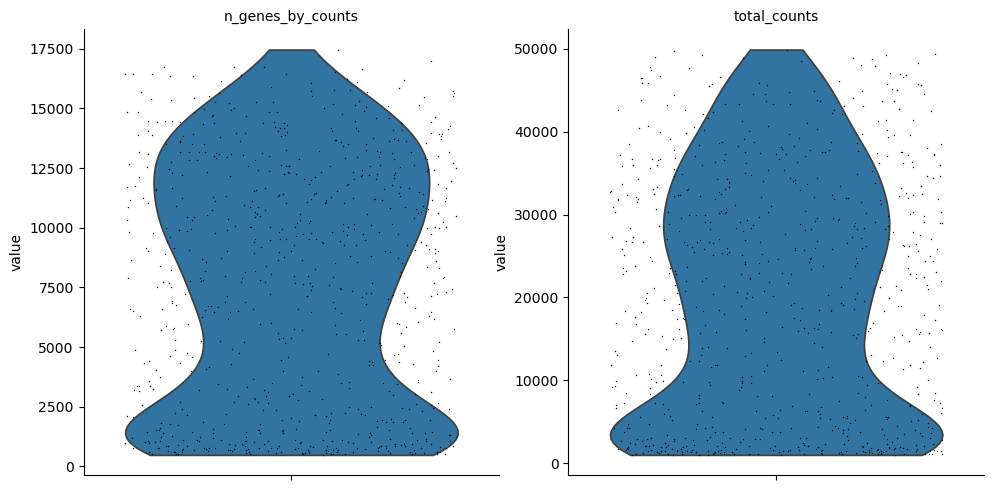

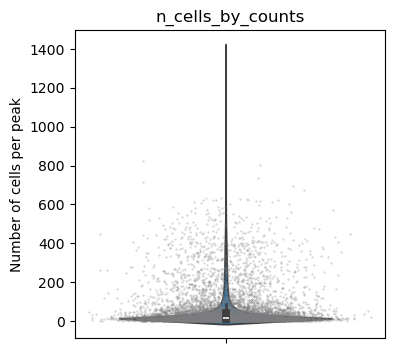

In [29]:
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)
plot_cells_by_counts_violin(atac)

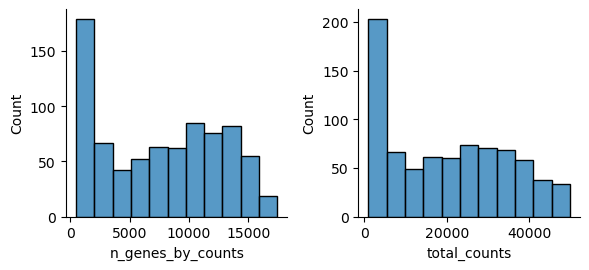

In [30]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'])

### ATAC-specific QC
There are a few expectations about how ATAC-seq data looks like as noted in the [hitchhiker’s guide to ATAC-seq data analysis](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-020-1929-3#citeas) for instance


#### Nucleosome Signal

Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7']
{'fragments': '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/K562_10x_raw/fragments.tsv.gz'}
/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/raw/K562_10x_raw/fragments.tsv.gz
chr1:0-1000000 chr1	10096	10198	AGTAAACAGACAGGTA-1	2


Fetching Regions...: 100%|█████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 40.74it/s]


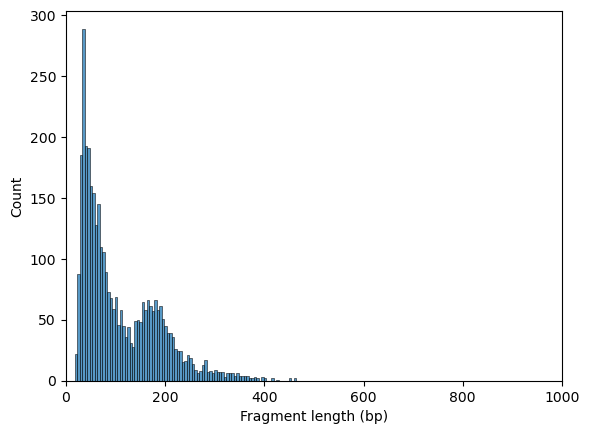

In [31]:
if frag_path is not None:
    index_file = str(frag_path) + ".tbi"
    if not Path(index_file).exists():
        print("Index file not found. Creating index file...")
        pysam.tabix_index(
            str(frag_path),
            preset="bed",
            force=True
        )
    
    tbx = pysam.TabixFile(str(frag_path))
    print(tbx.contigs[:20])

    # register the fragment file with the ATAC AnnData
    ac.tl.locate_fragments(atac, fragments=str(frag_path))

    print(atac.uns["files"])
    print(atac.uns["files"]["fragments"])
    # optional grouping column if you want one
    atac.obs["NS"] = 1

    def find_nonempty_region(tbx, chrom="chr1", window=1_000_000, max_end=200_000_000):
        for start in range(0, max_end, window):
            rows = list(tbx.fetch(chrom, start, start + window))
            if rows:
                return f"{chrom}:{start}-{start+window}", rows[0]
        return None, None

    region, example = find_nonempty_region(tbx, chrom="chr1")
    print(region, example)

    ac.pl.fragment_histogram(atac, region=region)
else:
    print("No fragment file provided, skipping fragment histogram plotting.")

The ratio of mono-nucleosome cut fragments to nucleosome-free fragments can be called nucleosome signal, and it can be estimated using a subset of fragments.

Reading Fragments: 100%|███████████████████████████████████████████| 1000000/1000000 [00:03<00:00, 306672.52it/s]


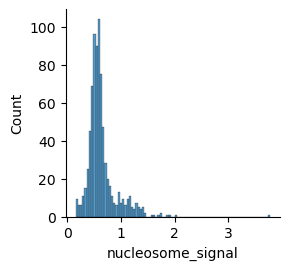

In [32]:
if frag_path is not None:
    ac.tl.nucleosome_signal(atac, n=1e6)
    mu.pl.histogram(atac, "nucleosome_signal", kde=False)
else:
    print("No fragment file provided, skipping nucleosome signal calculation.")

#### TSS Enrichment

We can expect chromatin accessibility enriched around transcription start sites (TSS) compared to accessibility of flanking regions. Thus this measure averaged across multiple genes can serve as one more quality control metric.

The positions of transcription start sites can be obtained from the interval field of the gene annotation in the rna modality:

In [33]:
if frag_path is not None:
    tss_df = pd.read_csv(
        tss_path,
        sep="\t",
        header=None,
        names=["tss_chrom", "tss_start", "tss_end", "tss_gene"]
    )

    var = rna.var.copy()
    var["original_var_name"] = var.index

    # Remove any old columns that could collide
    cols_to_drop = [
        "tss_chrom", "tss_start", "tss_end", "tss_gene",
        "Chromosome", "Start", "End", "interval"
    ]
    var = var.drop(columns=[c for c in cols_to_drop if c in var.columns], errors="ignore")

    # Merge gene annotations onto var
    var = (
        var.merge(
            tss_df,
            left_index=True,
            right_on="tss_gene",
            how="left"
        )
        .set_index("original_var_name")
    )

    var["interval"] = pd.NA
    mask = var["tss_chrom"].notna() & var["tss_start"].notna() & var["tss_end"].notna()

    var.loc[mask, "interval"] = (
        var.loc[mask, "tss_chrom"].astype(str) + ":" +
        var.loc[mask, "tss_start"].astype(int).astype(str) + "-" +
        var.loc[mask, "tss_end"].astype(int).astype(str)
    )

    var["Chromosome"] = var["tss_chrom"]
    var["Start"] = var["tss_start"]
    var["End"] = var["tss_end"]

    rna.var = var

    rna_tss = rna[:, rna.var["interval"].notna()].copy()
else:
    print("No TSS annotation file provided, skipping TSS annotation and subsetting.")

Create a DataFrame of gene TSS locations

In [34]:
genes = ac.tl.get_gene_annotation_from_rna(rna_tss)
genes.head(3)

,Chromosome,Start,End,gene_id,gene_name
original_var_name,,,,,
MIR1302-2HG,chr1,28589,28590,ENSG00000243485,MIR1302-2HG
LINC01409,chr1,778739,778740,ENSG00000237491,LINC01409
LINC01128,chr1,825138,825139,ENSG00000228794,LINC01128


TSS enrichment function will return an AnnData object with cells x bases dimensions where bases correspond to positions around TSS and are defined by extend_upstream and extend_downstream parameters, each of them being 1000 bp by default. It will also record tss_score in the original object.

Fetching Regions...: 100%|███████████████████████████████████████████████████| 1000/1000 [00:12<00:00, 80.57it/s]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


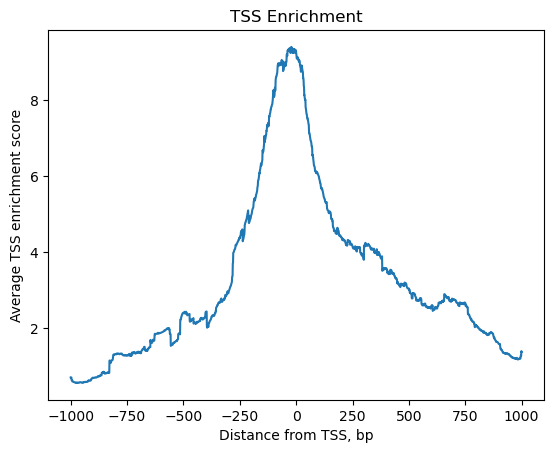

In [35]:
if frag_path is not None:
    tss = ac.tl.tss_enrichment(mdata, features=genes, n_tss=1000)

    # plot
    ac.pl.tss_enrichment(tss)
else:
    print("No fragment file provided, skipping TSS enrichment calculation.")

### Normalization

In [36]:
# Save original counts
atac.layers["counts"] = atac.X

There can be multiple options for ATAC-seq data normalisation.

One is latent semantic indexing that is frequently used for processing ATAC-seq datasets. First, it constructs term-document matrix from the original count matrix. Then the singular value decomposition (SVD) — the same technique that convential principal component analysis uses — is used to generate LSI components. Note that there are different flavours of computing TF-IDF, e.g. see this blog post about that.

TF-IDF normalisation is implemented in the muon’s ATAC module:

In [37]:
ac.pp.tfidf(atac, scale_factor=1e4)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_atac/preproc.py:106: RuntimeWarning: divide by zero encountered in divide
  idf = np.asarray(adata.shape[0] / counts.sum(axis=0)).reshape(-1)


Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [38]:
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)

/tmp/ipykernel_638701/27188036.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


### Feature Selection

We will label highly variable peaks that we’ll use for downstream analysis.

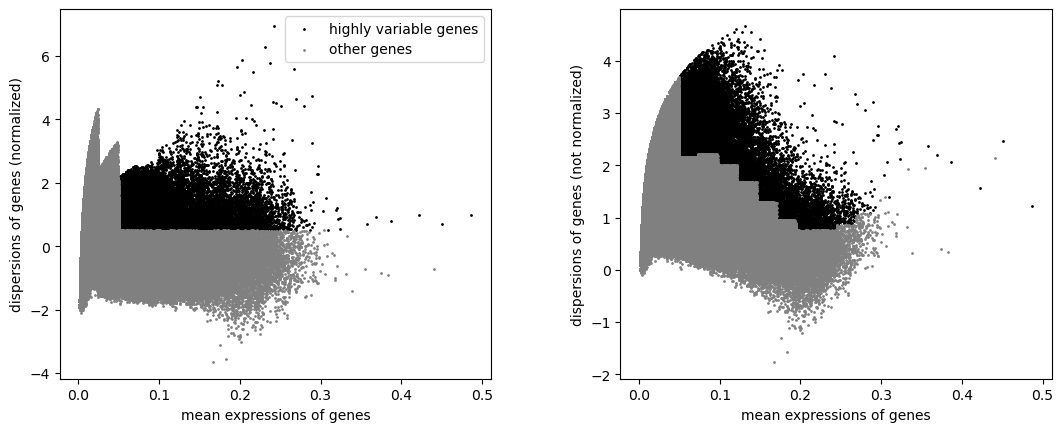

In [39]:
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
sc.pl.highly_variable_genes(atac)

Only keep highly-variable peaks.

In [40]:
# keep_genes = atac.var["highly_variable"]
# atac = atac[:, keep_genes]

In [41]:
np.sum(atac.var.highly_variable)

np.int64(21145)

### Scaling

For uniformity, and for consequent visualisation, we’ll save log-transformed counts in a .raw slot:

In [42]:
atac.raw = atac

## Analysis

After filtering out low-quality cells, normalising the counts matrix, and selecting highly variable peaks, we can already use this data for multimodal integration.

However, as in the case of gene expression, we will study this data individually first and will run PCA on the scaled matrix, compute cell neighbourhood graph, and perform clustering to define cell types. This might be useful later to compare cell type definition between modalities.

### LSI

When working on TF-IDF counts, `sc.tl.pca` or `ac.tl.lsi` can be used to get latent components, e.g.:

In [43]:
ac.tl.lsi(atac)

We find the first component is typically associated with number of peaks or counts per cell so it is reasonable to remove it:

In [44]:
atac.obsm['X_lsi'] = atac.obsm['X_lsi'][:,1:]
atac.varm["LSI"] = atac.varm["LSI"][:,1:]
atac.uns["lsi"]["stdev"] = atac.uns["lsi"]["stdev"][1:]

The respective neighbourhood graph can be generated with sc.tl.neighbors:

In [45]:
sc.pp.neighbors(atac, use_rep="X_lsi", n_neighbors=10, n_pcs=30)

### PCA

For this notebook, we are using PCA on the log-normalised counts in atac.X as described above.

In [46]:
sc.pp.scale(atac)
sc.tl.pca(atac)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


We can only colour our plots by cut counts in individual peaks with scanpy:

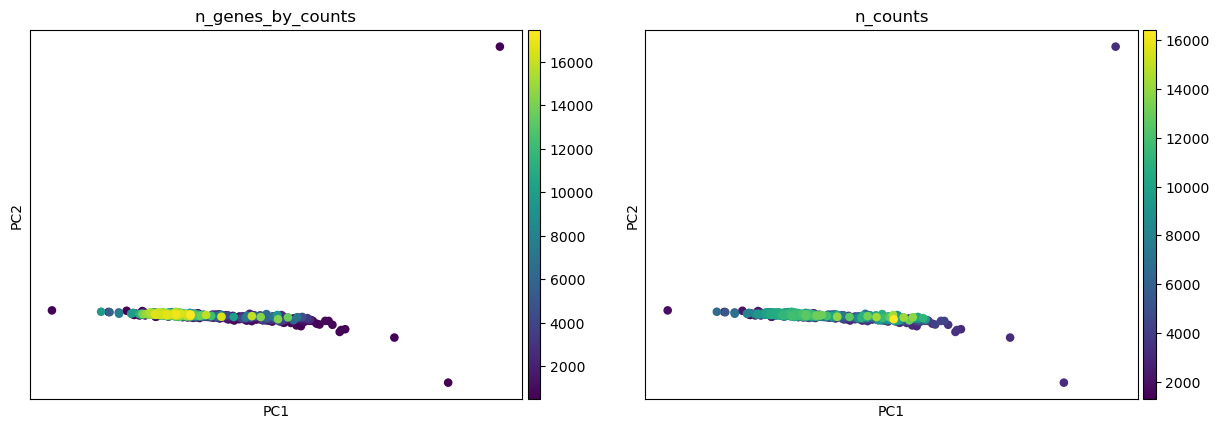

In [47]:
sc.pl.pca(atac, color=["n_genes_by_counts", "n_counts"])

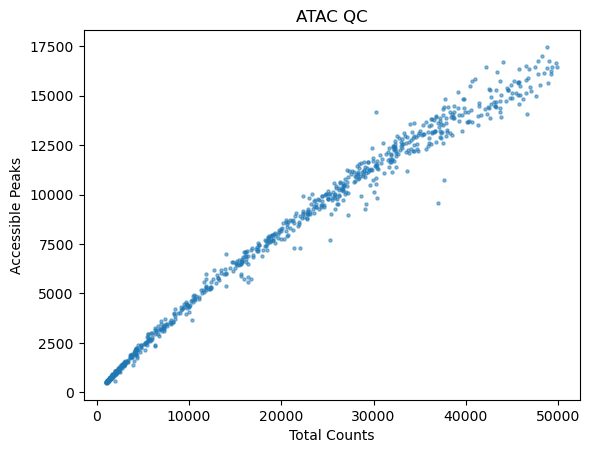

In [48]:
import matplotlib.pyplot as plt

plt.scatter(
    atac.obs["total_counts"],
    atac.obs["n_genes_by_counts"],
    s=5,
    alpha=0.5
)

plt.xlabel("Total Counts")
plt.ylabel("Accessible Peaks")
plt.title("ATAC QC")
plt.show()

With muon’s ATAC module, we can plot average values for cut counts in peaks of different types (promoter/distal) that are assigned to respective genes — just by providing gene names.

For that to work, we need the peak annotation table with `gene -> peak` correspondence. The `peak_annotation.tsv` file was detected and loaded automatically when we loaded the original data. Here is how the processed peak annotation table looks like:

In [49]:
def construct_peak_annotation(atac, save_dir: Path):
    """Construct a peak annotation table in 10x-style format, assigning each peak to a gene and distance based on TSS proximity."""
    
    # --------------------------------------------------
    # Inputs
    # --------------------------------------------------
    tss_path = "/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/hg38/gene_tss.bed"

    # 10x-style windows
    PROMOTER_UPSTREAM = 1000
    PROMOTER_DOWNSTREAM = 100
    DISTAL_MAX = 200_000

    # --------------------------------------------------
    # 1. Parse ATAC peaks
    # expects atac.var_names like chr1:1000-1500
    # --------------------------------------------------
    peaks = pd.DataFrame({"peak": atac.var_names.astype(str)})
    
    coords = peaks["peak"].str.extract(
        r"^(?P<chrom>[^:]+):(?P<start>\d+)-(?P<end>\d+)$"
    )

    if coords.isna().any().any():
        bad = peaks.loc[coords.isna().any(axis=1), "peak"].head(10).tolist()
        raise ValueError(f"Could not parse some peak names. Examples: {bad}")

    peaks = pd.concat([peaks, coords], axis=1)
    peaks["start"] = peaks["start"].astype(int)
    peaks["end"] = peaks["end"].astype(int)

    # --------------------------------------------------
    # 2. Load TSS BED
    # your BED columns are: chrom, start, end, gene symbol
    # --------------------------------------------------
    tss = pd.read_csv(
        tss_path,
        sep="\t",
        header=None,
        names=["chrom", "tss_start", "tss_end", "gene"]
    )

    # TSS BED appears to use a single-base TSS
    # Use tss_start as the TSS coordinate
    tss["tss"] = tss["tss_start"].astype(int)

    # Optional: if you have a protein-coding-only file, use it.
    # Otherwise this step will include all genes in the BED.
    # tss = tss[tss["gene_biotype"] == "protein_coding"].copy()

    # --------------------------------------------------
    # 3. Cross-join peaks and genes by chromosome
    # --------------------------------------------------
    cand = peaks.merge(
        tss[["chrom", "gene", "tss"]],
        on="chrom",
        how="inner"
    )

    # 10x signed distance:
    # positive if peak start is downstream of TSS
    # negative if peak end is upstream of TSS
    # zero if TSS overlaps peak
    cand["distance"] = np.where(
        cand["start"] > cand["tss"],
        cand["start"] - cand["tss"],
        np.where(
            cand["end"] < cand["tss"],
            cand["end"] - cand["tss"],
            0
        )
    )

    cand["abs_distance"] = cand["distance"].abs()

    # --------------------------------------------------
    # 4. PROMOTER peaks:
    # overlap promoter region [TSS-1000, TSS+100]
    # --------------------------------------------------
    cand["is_promoter"] = (
        (cand["end"] >= (cand["tss"] - PROMOTER_UPSTREAM)) &
        (cand["start"] <= (cand["tss"] + PROMOTER_DOWNSTREAM))
    )

    promoter = cand.loc[cand["is_promoter"], ["peak", "chrom", "start", "end", "gene", "distance"]].copy()
    promoter["peak_type"] = "promoter"

    # --------------------------------------------------
    # 5. DISTAL peaks:
    # within 200 kb of the CLOSEST TSS,
    # but not promoter for that same gene
    # --------------------------------------------------
    # find closest TSS gene per peak
    closest_idx = cand.groupby("peak")["abs_distance"].idxmin()
    closest = cand.loc[closest_idx, ["peak", "chrom", "start", "end", "gene", "distance", "abs_distance"]].copy()

    closest = closest.loc[closest["abs_distance"] <= DISTAL_MAX].copy()

    # remove cases where that peak is already promoter for that same gene
    promoter_pairs = set(zip(promoter["peak"], promoter["gene"]))
    closest["is_promoter_same_gene"] = [
        (p, g) in promoter_pairs for p, g in zip(closest["peak"], closest["gene"])
    ]

    distal = closest.loc[~closest["is_promoter_same_gene"], ["peak", "chrom", "start", "end", "gene", "distance"]].copy()
    distal["peak_type"] = "distal"

    # --------------------------------------------------
    # 6. INTERGENIC peaks:
    # peaks with no promoter or distal assignment
    # --------------------------------------------------
    assigned_peaks = set(promoter["peak"]) | set(distal["peak"])

    intergenic = peaks.loc[~peaks["peak"].isin(assigned_peaks), ["peak", "chrom", "start", "end"]].copy()
    intergenic["gene"] = ""
    intergenic["distance"] = np.nan
    intergenic["peak_type"] = "intergenic"

    # --------------------------------------------------
    # 7. Final table in 10x format
    # --------------------------------------------------
    peak_annotation_10x = pd.concat(
        [
            promoter[["chrom", "start", "end", "gene", "distance", "peak_type"]],
            distal[["chrom", "start", "end", "gene", "distance", "peak_type"]],
            intergenic[["chrom", "start", "end", "gene", "distance", "peak_type"]],
        ],
        axis=0,
        ignore_index=True
    ).sort_values(["chrom", "start", "end", "gene", "peak_type"])
    
    peak_annotation_10x = peak_annotation_10x.dropna()

    print(peak_annotation_10x.head(20))
    print(peak_annotation_10x["peak_type"].value_counts(dropna=False))

    # save as 10x-style TSV
    out_path = save_dir / "atac_peak_annotation.tsv"
    if not out_path.parent.exists():
        out_path.parent.mkdir(parents=True)
    peak_annotation_10x.to_csv(out_path, sep="\t", index=False)
    print(f"Saved to {out_path}")

if not (SAMPLE_PROCESSED_DATA_DIR / "atac_peak_annotation.tsv").exists():
    construct_peak_annotation(atac, SAMPLE_DATA_DIR)
else:
    print("Peak annotation already exists, skipping construction.")

      chrom   start     end       gene  distance peak_type
67672  chr1  115460  115953     CICP27  -15072.0    distal
83618  chr1  605411  605458   MTND1P23  -23604.0    distal
5      chr1  629038  635087   MTATP6P1       0.0  promoter
4      chr1  629038  635087   MTATP8P1       0.0  promoter
2      chr1  629038  635087   MTCO1P12       0.0  promoter
3      chr1  629038  635087   MTCO2P12       0.0  promoter
6      chr1  629038  635087   MTCO3P12       0.0  promoter
0      chr1  629038  635087   MTND1P23       0.0  promoter
1      chr1  629038  635087   MTND2P28       0.0  promoter
7      chr1  778232  779279  LINC01409       0.0  promoter
8      chr1  817064  817603     FAM87B       0.0  promoter
84827  chr1  825854  825970  LINC01128     716.0    distal
84828  chr1  827128  827849  LINC01128    1990.0    distal
84835  chr1  831574  832493  LINC01128    6436.0    distal
84888  chr1  842663  843258  LINC01128   17525.0    distal
9      chr1  869645  870348     FAM41C       0.0  promot

In [50]:
ac.tl.add_peak_annotation(atac, annotation=str(SAMPLE_DATA_DIR / "atac_peak_annotation.tsv"))

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_atac/tools.py:118: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pa.loc[pa.distance.isnull(), "distance"] = ""


In [51]:
atac.uns['atac']['peak_annotation'].tail()

,peak,distance,peak_type
gene,,,
CTBP2P1,chrY:56833355-56834285,-20959,distal
CTBP2P1,chrY:56836683-56837350,-17894,distal
CTBP2P1,chrY:56843140-56844060,-11184,distal
CTBP2P1,chrY:56847559-56847603,-7641,distal
CTBP2P1,chrY:56849490-56849625,-5619,distal


Now we can plot average cut values in peaks corresponding to genes just by providing a gene name. By default, values in `atac.raw` are used for plotting.

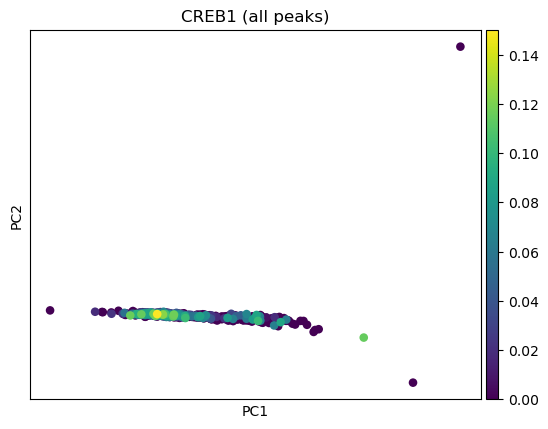

In [52]:
ac.pl.pca(atac, color='CREB1', average="total")

We can also average peaks of each type separately:

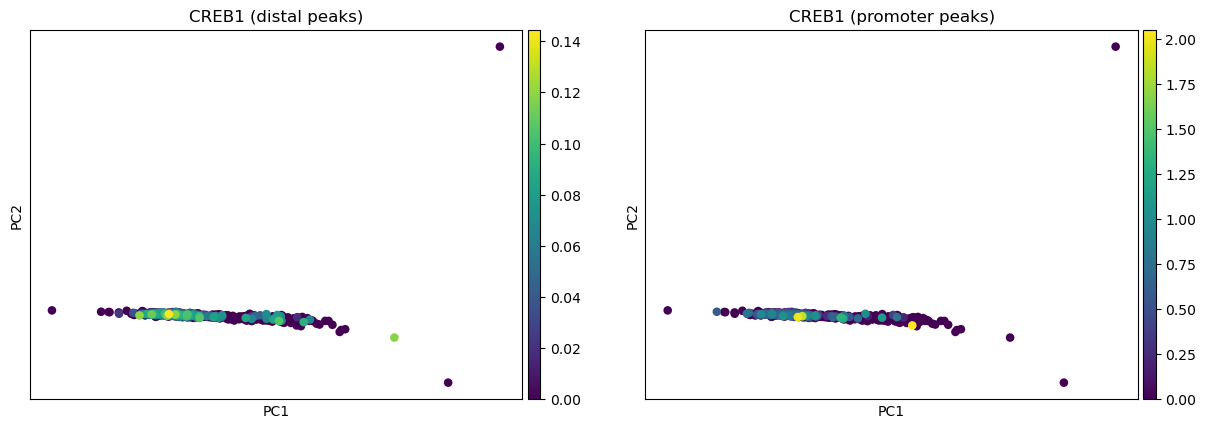

In [53]:
ac.pl.pca(atac, color='CREB1', average="peak_type")

We see how this component space here resembles the one based on gene expression from the previous notebook. Now we will compute a neighbourhood graph for cells that we’ll use for clustering later on.

### Neighbors

In [54]:
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=30)

### Non-linear dimensionality reduction and clustering

To stay comparable to the gene expression notebook, we will use leiden to cluster cells. We’ll use UMAP latent space for visualisation below.

In [55]:
sc.tl.umap(atac, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(atac, flavor="igraph", n_iterations=2)

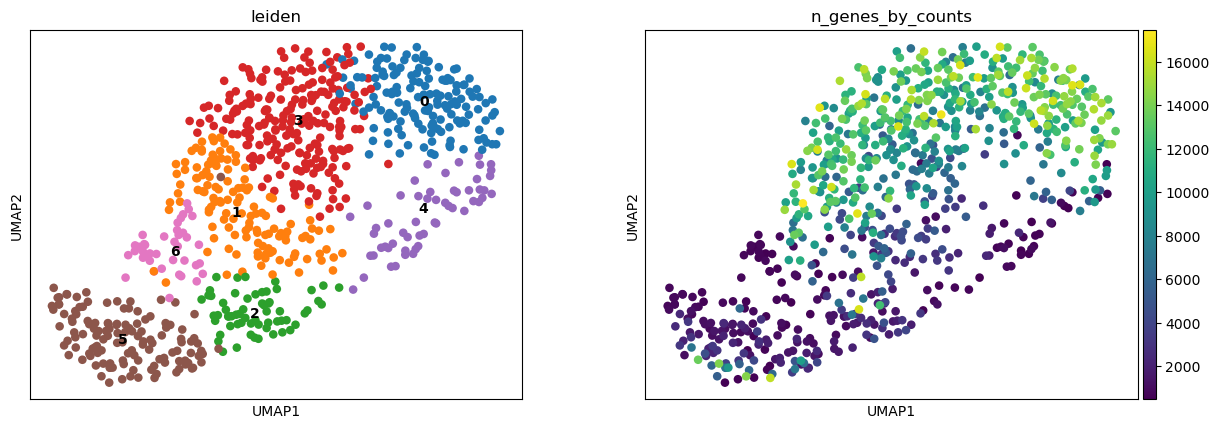

In [56]:
sc.pl.umap(atac, color=["leiden", "n_genes_by_counts"], legend_loc="on data")

Again, we can use the functionality of the ATAC module in muon to color plots by cut values in peaks correspoonding to a certain gene:

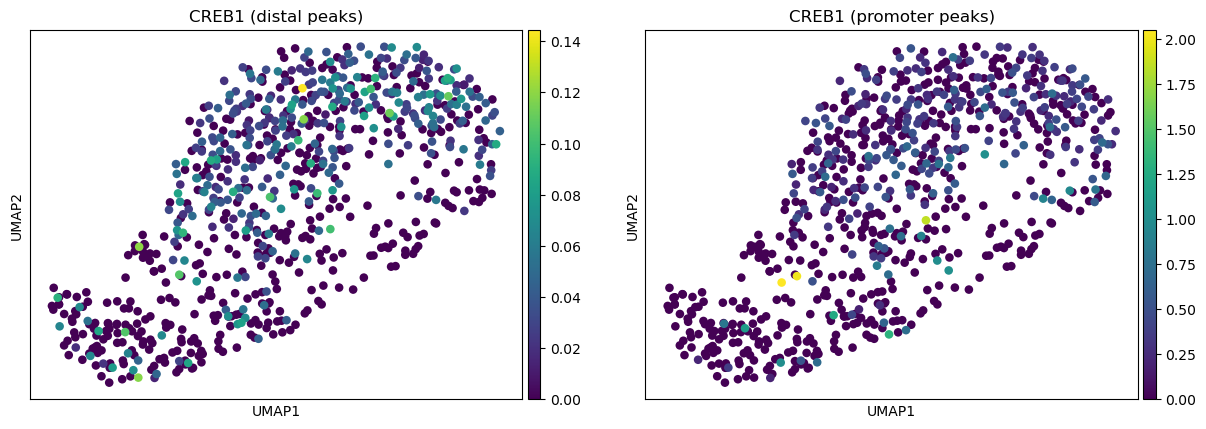

In [57]:
ac.pl.umap(atac, color=["CREB1"], average="peak_type")

### Marker Genes and Celltypes

We will now define cell types based on chromatin accessibility.

In [58]:
ac.tl.rank_peaks_groups(atac, 'leiden', method='t-test')

In [59]:
result = atac.uns["rank_genes_groups"]
groups = result["names"].dtype.names

pd.set_option("display.max_columns", 50)

df = pd.DataFrame({
    f"{group}_{key[:1]}": pd.Series(result[key][group])
    for group in groups
    for key in ["names", "genes", "pvals"]
    if key in result
})

df.head(10)

,0_n,0_g,0_p,1_n,1_g,1_p,2_n,2_g,2_p,3_n,3_g,3_p,4_n,4_g,4_p,5_n,5_g,5_p,6_n,6_g,6_p
0,chr12:123387121-123390448,KMT5A,8.434234e-16,chr10:37856701-37858633,ZNF248-AS1,0.000078,chr3:93470158-93470988,"MTND1P15, MTND2P13",0.001699,chr10:43415371-43419059,SNORD3J,6.893429e-09,chr5:134923235-134928606,"MTCYBP18, MTND3P25, MTND4LP30, MTND4P12, MTND5...",3.322851e-07,chr3:93470158-93470988,"FIBCD1, FIBCD1-AS1, QRFP",1.493436e-31,chr2:118921618-118922010,MARCO,0.017317
1,chr1:167626784-167636105,RCSD1,9.906039e-16,chr10:109922496-109924419,ADD3-AS1,0.000092,chr17:22521030-22525985,CCDC9,0.002493,chr6:26295475-26298264,H4C8,1.123033e-08,chr17:22521030-22525985,"MTND1P15, MTND2P13",5.712099e-07,chr9:130876936-130953285,"IGLC4, IGLC5, IGLC6, IGLC7, IGLJ4, IGLJ5, IGLJ...",2.278467e-21,chr1:201551508-201552467,NAV1,0.028489
2,chr14:24093455-24096044,PCK2,2.119835e-14,chr10:35191428-35192177,ATP6V1G1P4,0.000118,chr19:47255880-47258285,INSIG1,0.004631,chr9:129860387-129863920,MIR6855,9.885811e-09,chr19:1852293-1865360,"KLF16, KLF16-AS1",3.654883e-06,chr22:22906747-22947659,"FBXW4P1, RN7SL263P",4.227056e-19,chr5:37738001-37738552,RNU6-484P,0.029859
3,chr7:106655227-106663092,CCDC71L,1.633938e-14,chr11:73383240-73386550,RELT,0.000317,chr7:155295027-155301488,"ATP5F1D, MIDN",0.012173,chr6:16236228-16242525,GMPR,1.025192e-08,chr19:9818411-9820084,RPL10P15,6.511584e-06,chr22:23194970-23290828,RSPH14,4.899193e-18,chr1:174849042-174849637,NDUFAF4P4,0.030872
4,chr1:52054067-52057806,BTF3L4,7.024534e-14,chr15:79977143-79979414,BCL2A1,0.000654,chr19:1239470-1253938,BRD2,0.013606,chr5:90408447-90411076,CETN3,1.521752e-08,chr1:629038-635087,"MTATP6P1, MTATP8P1, MTCO1P12, MTCO2P12, MTCO3P...",6.375049e-06,chr22:23082165-23129627,"IGLV2-23, IGLV3-21, IGLV3-22, IGLV3-24, IGLV3-...",1.726201e-16,chr12:114955397-114956035,LINC00315,0.031860
5,chr1:207518522-207521868,CR1,1.663873e-13,chr12:113420302-113423803,SDSL,0.000691,chr6:32966610-32974887,"HMMR, NUDCD2",0.017196,chr7:104982342-104986954,KMT2E,1.915926e-08,chr16:351194-354279,MRPL28,1.053504e-05,chr22:22678623-22716081,LAMC3,2.455486e-15,chr21:45318684-45319317,RNA5SP206,0.033657
6,chr7:106566616-106574140,CTB-30L5.1,1.006660e-13,chr11:78289463-78293854,GAB2,0.000868,chr5:163456798-163463149,WASHC4,0.023014,chr22:19940182-19948723,COMT,1.954378e-08,chr19:18519915-18523103,FKBP8,1.175458e-05,chr9:130975119-131017668,"MTND1P15, MTND2P13",2.764004e-15,chr6:32092821-32093641,DSTNP5,0.035822
7,chr1:212857017-212861619,"FLVCR1, FLVCR1-DT",1.988521e-13,chr2:10119528-10125005,RRM2,0.000884,chr12:105106468-105110393,C9ORF163,0.028662,chr3:180988975-180991200,"DNAJC19, SOX2-OT",2.462571e-08,chr19:1264760-1276925,"CIRBP-AS1, FAM174C",1.494045e-05,chr17:22521030-22525985,LAMC3,4.932540e-15,chr2:204280148-204280724,CLGN,0.038484
8,chr8:23527213-23531336,SLC25A37,4.497701e-13,chr7:135650501-135651630,RPL15P11,0.001181,chr9:136481639-136484388,"DNAJB1, TECR",0.036742,chr5:149320618-149321569,GRPEL2,3.046414e-08,chr19:5902750-5905450,VMAC,1.561197e-05,chr9:131018284-131044006,"MTCYBP18, MTND3P25, MTND4LP30, MTND4P12, MTND5...",9.639764e-13,chr4:140426623-140428702,ZFAND3-DT,0.039762
9,chr1:47178916-47184375,"CYP4A22-AS1, LINC00853, PDZK1IP1",7.890376e-13,chr4:150327390-150330863,LRBA,0.001499,chr19:14515298-14520076,SMAD4,0.036818,chr17:39979516-39981937,PSMD3,2.877223e-08,chr11:64183359-64187677,STIP1,3.821286e-05,chr5:134923235-134928606,RNU6-881P,6.980849e-13,chr6:37731570-37732365,KLK12,0.045007


## Saving progress to disk

In [60]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/atac"), atac)

---

# Integrating Gene Expression and Chromatin Accessibility

In this section, we will see how to learn a latent space jointly on two omics.

In [61]:
mdata = mu.read(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu"))
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 1595 × 212893
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  2 modalities
    rna:	1434 x 42068
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'keep_tf', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	782 x 170825
      obs:	'n_genes_by_counts', 'total_counts', 'NS', 'nucleosome_signal', 'tss_score', 'n_counts', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'species', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'atac', 'files', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
      obsm:	'X_lsi', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

In each modality, only cells passing respective QC are retained. For the multimodal data integration, we will use only cells that are present for both modalities:

In [62]:
mu.pp.intersect_obs(mdata)
mdata.shape

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


(621, 212893)

## Perform Integration

We will now run multi-omic factor analysis — a group factor analysis method that will allow us to learn an interpretable latent space jointly on both modalities. Intuitively, it can be viewed as a generalisation of PCA for multi-omics data. More information about this method can be found on the MOFA website.

The time required to train the model depends on the number of cells and features as well as on hardware specs. For the current dataset, it takes 4 minutes on the GeForce RTX 2080 Ti NVIDIA card. Only highly variable features are used by default.

In [63]:
mu.tl.mofa(mdata, outfile=SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}_rna_atac.h5mu")


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Loaded view='rna' group='group1' with N=621 samples and D=7323 features...
Loaded view='atac' group='group1' with N=621 samples and D=21145 features...




Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Li

After the training, the embedding will be added to the `obsm` slot of the `mdata`:

In [64]:
mdata.obsm['X_mofa'].shape

(621, 10)

To visualise all the factors together, we’ll use a non-linear dimensionality reduction method such as UMAP to display the embedding in 2D:

In [65]:
sc.pp.neighbors(mdata, use_rep="X_mofa")
sc.tl.umap(mdata)

In [66]:
sc.tl.umap(mdata, min_dist=.2, spread=1., random_state=10)

Conventional clustering can now be performed based on the MOFA embeddings and also can be visualised on the same UMAP:

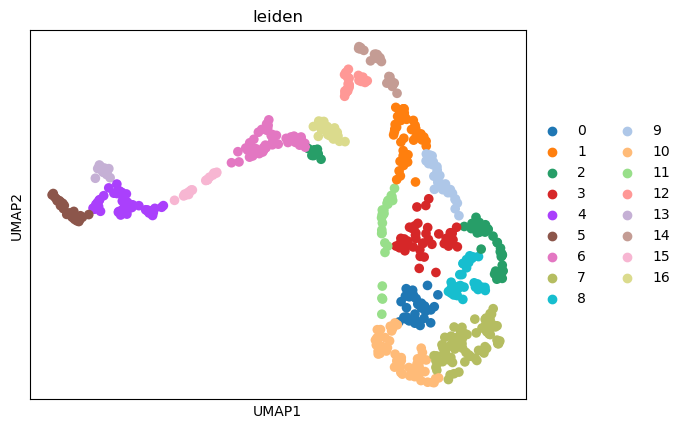

In [67]:
sc.tl.leiden(mdata, flavor="igraph", n_iterations=2)
sc.pl.umap(mdata, color=["leiden"])

Individual features from modalities are also available when plotting embeddings:

In [68]:
# mu.pl.umap(mdata, color=["CREB1", "chr11:109011392-109012310"])

We can also generate custom plots with matplotlib and seaborn:

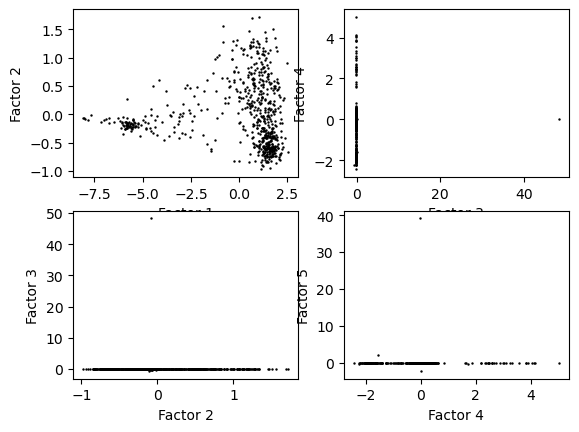

In [69]:
df = pd.DataFrame(mdata.obsm["X_mofa"])
df.columns = [f"Factor {i+1}" for i in range(df.shape[1])]

plot_scatter = lambda i, ax: sns.scatterplot(data=df, x=f"Factor {i+1}", y=f"Factor {i+2}", color="black", linewidth=0, s=3, ax=ax)

fig, axes = plt.subplots(2, 2)
for i in range(4):
    plot_scatter(i, axes[i%2][i//2])

## Ranking genes and peaks

In [70]:
mdata["rna"].obs["leiden_joint"] = mdata.obs["leiden"]
mdata["atac"].obs["leiden_joint"] = mdata.obs["leiden"]

In [71]:
sc.tl.rank_genes_groups(mdata['rna'], 'leiden_joint', method='t-test_overestim_var')

In [72]:
ac.tl.rank_peaks_groups(mdata['atac'], 'leiden_joint', method='t-test_overestim_var')

## Listing differentially expressed genes and differentially accessible peaks

In [73]:
result = {}
result['rna'] = mdata['rna'].uns['rank_genes_groups']
result['rna']['genes'] = result['rna']['names']
result['atac'] = mdata['atac'].uns['rank_genes_groups']

groups = result['rna']['names'].dtype.names
pd.set_option("display.max_columns", 200)
pd.DataFrame(
    {mod + ':' + group + '_' + key[:1]: pd.Series(result[mod][key][group])[:10]
    for group in groups for key in ['names', 'genes', 'pvals']
    for mod in mdata.mod.keys()})

,rna:0_n,atac:0_n,rna:0_g,atac:0_g,rna:0_p,atac:0_p,rna:1_n,atac:1_n,rna:1_g,atac:1_g,rna:1_p,atac:1_p,rna:2_n,atac:2_n,rna:2_g,atac:2_g,rna:2_p,atac:2_p,rna:3_n,atac:3_n,rna:3_g,atac:3_g,rna:3_p,atac:3_p,rna:4_n,atac:4_n,rna:4_g,atac:4_g,rna:4_p,atac:4_p,rna:5_n,atac:5_n,rna:5_g,atac:5_g,rna:5_p,atac:5_p,rna:6_n,atac:6_n,rna:6_g,atac:6_g,rna:6_p,atac:6_p,rna:7_n,atac:7_n,rna:7_g,atac:7_g,rna:7_p,atac:7_p,rna:8_n,atac:8_n,rna:8_g,atac:8_g,rna:8_p,atac:8_p,rna:9_n,atac:9_n,rna:9_g,atac:9_g,rna:9_p,atac:9_p,rna:10_n,atac:10_n,rna:10_g,atac:10_g,rna:10_p,atac:10_p,rna:11_n,atac:11_n,rna:11_g,atac:11_g,rna:11_p,atac:11_p,rna:12_n,atac:12_n,rna:12_g,atac:12_g,rna:12_p,atac:12_p,rna:13_n,atac:13_n,rna:13_g,atac:13_g,rna:13_p,atac:13_p,rna:14_n,atac:14_n,rna:14_g,atac:14_g,rna:14_p,atac:14_p,rna:15_n,atac:15_n,rna:15_g,atac:15_g,rna:15_p,atac:15_p,rna:16_n,atac:16_n,rna:16_g,atac:16_g,rna:16_p,atac:16_p
0,CCDC26,chr3:177284180-177285052,CCDC26,LINC00501,0.000005,0.004811,SLC25A37,chr3:4223910-4226105,SLC25A37,SETMAR,2.853432e-13,0.000063,HNRNPA1,chr6:67880839-67891053,HNRNPA1,ERVH-3,0.000132,0.002964,DTL,chr22:43969192-43971506,DTL,RPL35AP36,0.000004,0.006103,Gm42418,chr17:22521030-22525985,Gm42418,"MTND1P15, MTND2P13",1.287171e-36,7.097480e-15,Malat1,chr19:1019824-1022188,Malat1,RNU6-2,2.225429e-35,0.015240,CREBRF,chr17:4721333-4722174,CREBRF,MED11,0.000017,0.006611,CCDC26,chr8:129580482-129584896,CCDC26,MIR3686,3.866848e-13,0.000040,MT-CO3,chr1:25548098-25551118,MT-CO3,LDLRAP1,0.000080,0.005061,EPB41,chr7:471159-472597,EPB41,PDGFA,0.000421,0.015103,CCDC26,chr8:127957516-127962143,CCDC26,MIR1205,5.900895e-14,0.000081,LTBP1,chr3:173005990-173008539,LTBP1,SPATA16,0.000004,0.000344,NEAT1,chr17:78734972-78737778,NEAT1,RNU6-638P,0.000005,0.000423,Gm42418,chr5:134923235-134928606,Gm42418,"MTCYBP18, MTND3P25, MTND4LP30, MTND4P12, MTND5...",5.941309e-09,1.942514e-07,NEAT1,chr15:32869557-32870905,NEAT1,FMN1,2.582014e-07,0.003071,Lars2,chr6:27683356-27685766,Lars2,LINC01012,0.000017,0.009504,PCED1B,chr15:79977143-79979414,PCED1B,BCL2A1,2.275769e-08,0.002229
1,SPATA5,chr5:91218773-91220173,SPATA5,LUCAT1,0.000053,0.007671,NARF,chr11:48060786-48062165,NARF,MIR3161,4.202900e-13,0.000189,AIG1,chr3:52286880-52289215,AIG1,"GLYCTK, GLYCTK-AS1",0.000202,0.008158,BRCA1,chr17:33870323-33875401,BRCA1,TLK2P1,0.000005,0.009077,Eef1a1,chr5:134923235-134928606,Eef1a1,"MTCYBP18, MTND3P25, MTND4LP30, MTND4P12, MTND5...",1.550429e-25,2.270006e-13,Ankrd11,chr1:201184753-201185345,Ankrd11,IGFN1,4.272089e-28,0.026797,FAM168B,chr10:130109630-130111938,FAM168B,C10ORF143,0.000556,0.012316,AL034397.3,chr3:32047943-32050106,AL034397.3,NIFKP7,9.809603e-14,0.000374,MT-ATP8,chr19:1217276-1218477,MT-ATP8,CBARP-DT,0.000187,0.009847,DOCK11,chr12:51898952-51899345,DOCK11,ACVRL1,0.000913,0.025311,PPM1E,chr7:73622500-73625048,PPM1E,MLXIPL,1.044793e-12,0.000138,CEP192,chr4:189838489-189839893,CEP192,LINC01596,0.000021,0.000639,P4HA1,chr1:117695862-117697753,P4HA1,VDAC2P3,0.000080,0.002568,Rpl39,chr3:93470158-93470988,Rpl39,"FIBCD1, FIBCD1-AS1, QRFP",3.636358e-08,3.811032e-06,MOB1B,chr15:82849162-82850551,MOB1B,HOMER2,7.807841e-07,0.006469,Gm42418,chr3:93470158-93470988,Gm42418,MLXIP,0.000052,0.014592,CD84,chr3:42012358-42015480,CD84,TRAK1,3.619561e-06,0.003170
2,AP000561.1,chrX:11350890-11354054,AP000561.1,GOT2P7,0.000080,0.006630,MOB1B,chr7:155323376-155325080,MOB1B,INSIG1,2.273977e-11,0.000273,MT-CYB,chr10:132163299-132163916,MT-CYB,JAKMIP3-AS1,0.000244,0.009476,AC093515.1,chr15:39516812-39517897,AC093515.1,THBS1,0.000016,0.010582,Rpl32,chr3:93470158-93470988,Rpl32,"MTATP6P1, MTATP8P1, MTCO1P12, MTCO2P12, MTCO3P...",1.160921e-24,1.855471e-08,Mllt10,chr19:16894059-16898255,Mllt10,CPAMD8,7.027109e-25,0.026822,YTHDC1,chr10:119177728-119179533,YTHDC1,PRDX3,0.000751,0.012960,AIG1,chr1:19325199-19326228,AIG1,SLC66A1,9.845005e-13,0.000555,NUP210,chr7:66113883-66116198,NUP210,CRCP,0.000125,0.009358,VPS54,chr1:166166410-166167626,VPS54,FAM78B,0.001188,0.025735,THRB,chr1:231065285-23106

In [74]:
print(mdata)

MuData object with n_obs × n_vars = 621 × 212893
  obs:	'leiden'
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'leiden', 'leiden_colors'
  obsm:	'X_mofa', 'X_umap'
  varm:	'LFs'
  obsp:	'distances', 'connectivities'
  2 modalities
    rna:	621 x 42068
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_joint'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'keep_tf', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap', 'rank_genes_groups'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', '

# Save Processed Data

In [75]:
import scipy.sparse as sp

def _adata_to_feature_by_cell_df(adata: ad.AnnData) -> pd.DataFrame:
    """
    Convert an AnnData object from cell x feature to feature x cell DataFrame.
    Preference order:
      1. adata.layers["log1p"]
      2. adata.layers["counts"]
      3. adata.X
    """
    if "log1p" in adata.layers:
        X = adata.layers["log1p"]
    elif "counts" in adata.layers:
        X = adata.layers["counts"]
    else:
        X = adata.X

    if sp.issparse(X):
        arr = X.T.toarray()
    else:
        arr = np.asarray(X, dtype=np.float32).T

    return pd.DataFrame(
        arr,
        index=adata.var_names.astype(str),
        columns=adata.obs_names.astype(str),
    )

def standardize_name(name: str) -> str:
    """Convert gene/motif name to upper style."""
    if not isinstance(name, str):
        return name
    return name.upper()

processed_rna_file = SAMPLE_PROCESSED_DATA_DIR / "scRNA_seq_processed.parquet"
processed_atac_file = SAMPLE_PROCESSED_DATA_DIR / "scATAC_seq_processed.parquet"

adata_rna_file = SAMPLE_PROCESSED_DATA_DIR / "adata_RNA.h5ad"
adata_atac_file = SAMPLE_PROCESSED_DATA_DIR / "adata_ATAC.h5ad"
mdata_file = PROCESSED_DATA_DIR / "multiome_processed.h5mu"

# Pull modalities from MuData
adata_rna = mdata["rna"]
adata_atac = mdata["atac"]

# Convert to feature x cell DataFrames
processed_rna_df = _adata_to_feature_by_cell_df(adata_rna).astype("float32")
processed_atac_df = _adata_to_feature_by_cell_df(adata_atac).astype("float32")

# Standardize RNA gene names
processed_rna_df.index = processed_rna_df.index.astype(str).map(standardize_name)

# Save parquet outputs
processed_rna_df.to_parquet(processed_rna_file, engine="pyarrow", compression="snappy")
processed_atac_df.to_parquet(processed_atac_file, engine="pyarrow", compression="snappy")

# Save modality-level AnnData files
adata_rna.write_h5ad(adata_rna_file)
adata_atac.write_h5ad(adata_atac_file)

# Optional: save the full MuData object too
mdata.write(mdata_file)

# Create Metacells

In [76]:
def plot_W_subset(W, n_cells=200, title=""):
    if sp.issparse(W):
        W_sub = W[:n_cells, :n_cells].toarray()
    else:
        W_sub = np.asarray(W[:n_cells, :n_cells])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        W_sub,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.5}
    )
    plt.title(title)
    plt.xlabel("Neighbor Cells")
    plt.ylabel("Cells")
    plt.tight_layout()
    plt.show()

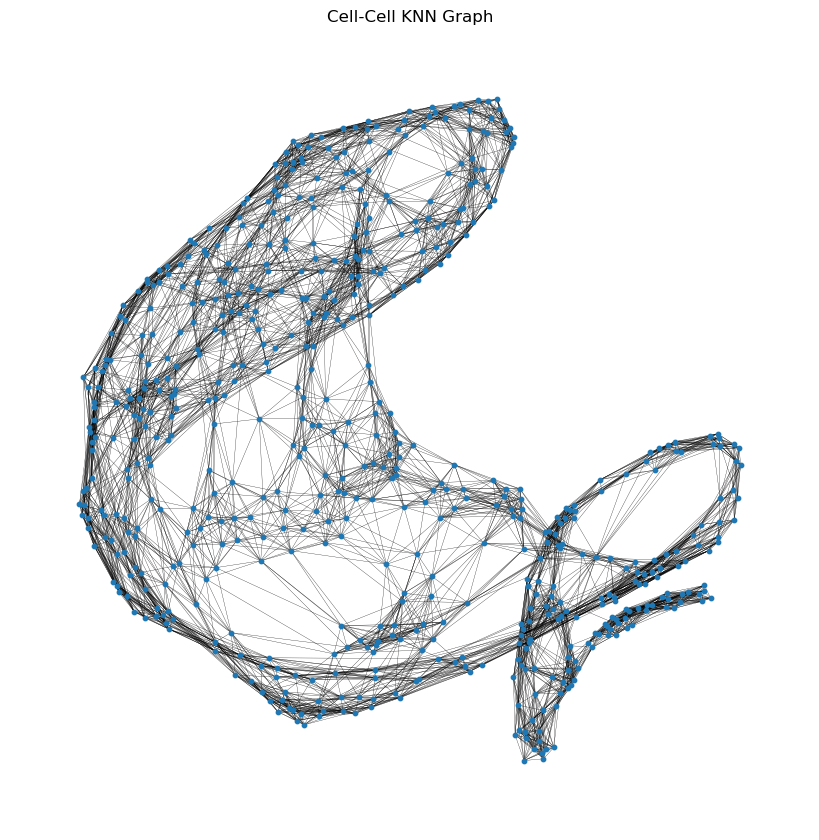

In [77]:
import networkx as nx
W_sparse = mdata.obsp["connectivities"].tocsr().astype(np.float32)

G = nx.from_scipy_sparse_array(W_sparse)

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    node_size=10,
    width=0.2,
    with_labels=False
)
plt.title("Cell-Cell KNN Graph")
plt.show()

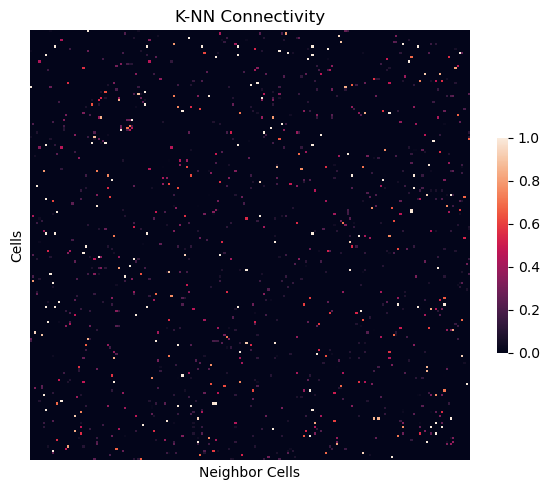

In [78]:
# Base connectivities between cells from the K-NN graph
W = mdata.obsp["connectivities"].tocsr().astype(np.float32)

plot_W_subset(W, title="K-NN Connectivity")

Add the cell identity to the connections as 1's

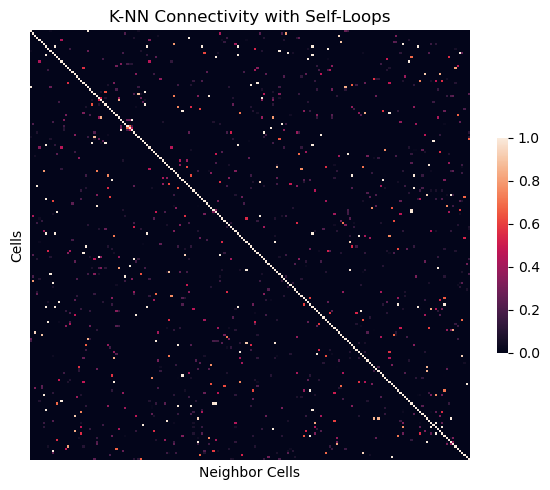

In [79]:
W = W + sp.diags(np.full(W.shape[0], 1, dtype=np.float32), format="csr")

plot_W_subset(W, title="K-NN Connectivity with Self-Loops")

Row-normalize so that each row adds to 1

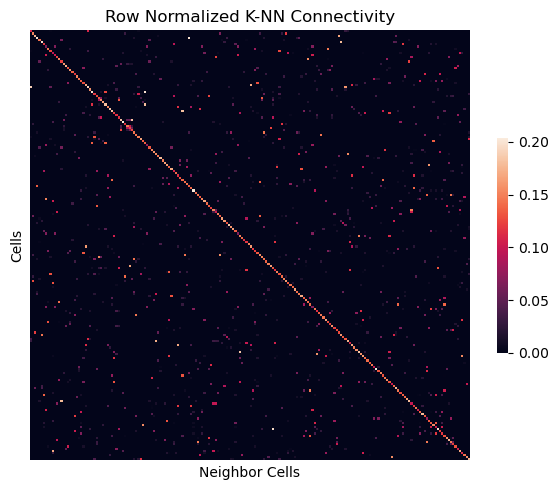

In [80]:
def row_norm(mat: sp.csr_matrix) -> sp.csr_matrix:
    row_sum = np.asarray(mat.sum(axis=1)).ravel()
    row_sum[row_sum == 0] = 1.0
    inv = sp.diags(1.0 / row_sum, dtype=np.float32)
    return inv @ mat

W = row_norm(W)

plot_W_subset(W, title="Row Normalized K-NN Connectivity")

Multi-hop diffusion to determine how much each cell's neighbors should be blended with its own expression.

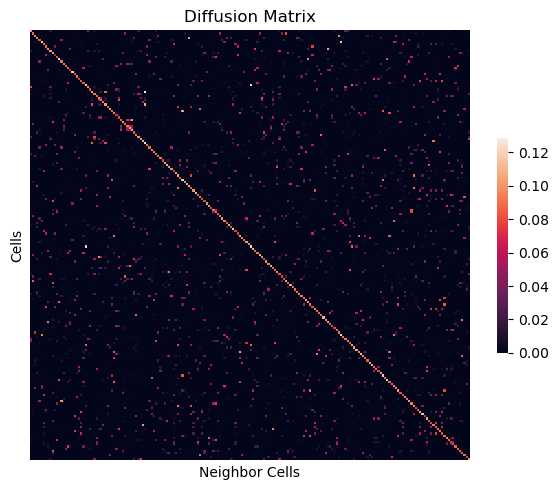

In [81]:
HOPS=2

W_h = W
for _ in range(1, int(HOPS)):
    W_h = W_h @ W 
    W_h = row_norm(W_h)
W = W_h

# Final row normalization to make sure rows sum to 1
W = row_norm(W)

plot_W_subset(W, title="Diffusion Matrix")

In [82]:
G = nx.from_scipy_sparse_array(W)
G.remove_edges_from(nx.selfloop_edges(G))
influence = np.array(W.sum(axis=0)).flatten()

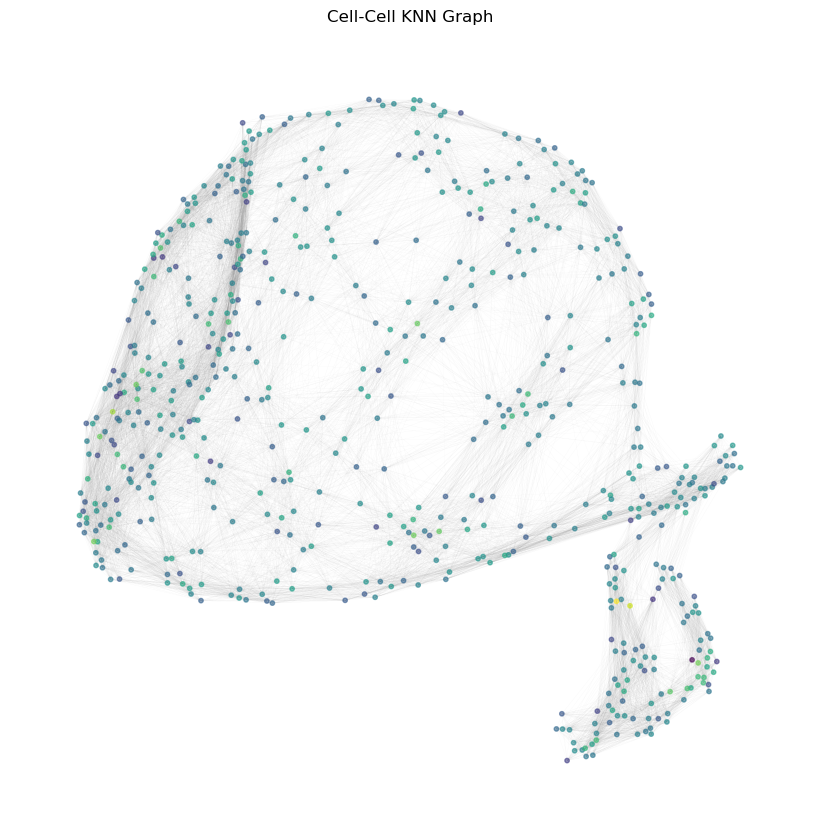

In [83]:
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    node_size=10,
    width=0.02,
    with_labels=False,
    node_color=influence,
    cmap="viridis",
    edge_color="gray",
    alpha=0.6,
)
plt.title("Cell-Cell KNN Graph")
plt.show()

Blend the expression of each cell with its neighbors based on the multi-hop diffusion mask.

In [84]:
X_rna = sp.csr_matrix(np.asarray(mdata["rna"].X, dtype=np.float32, order="C"))
X_atac = sp.csr_matrix(np.asarray(mdata["atac"].X, dtype=np.float32, order="C"))

X_rna_soft = W @ X_rna      # cells × genes
X_atac_soft = W @ X_atac    # cells × peaks

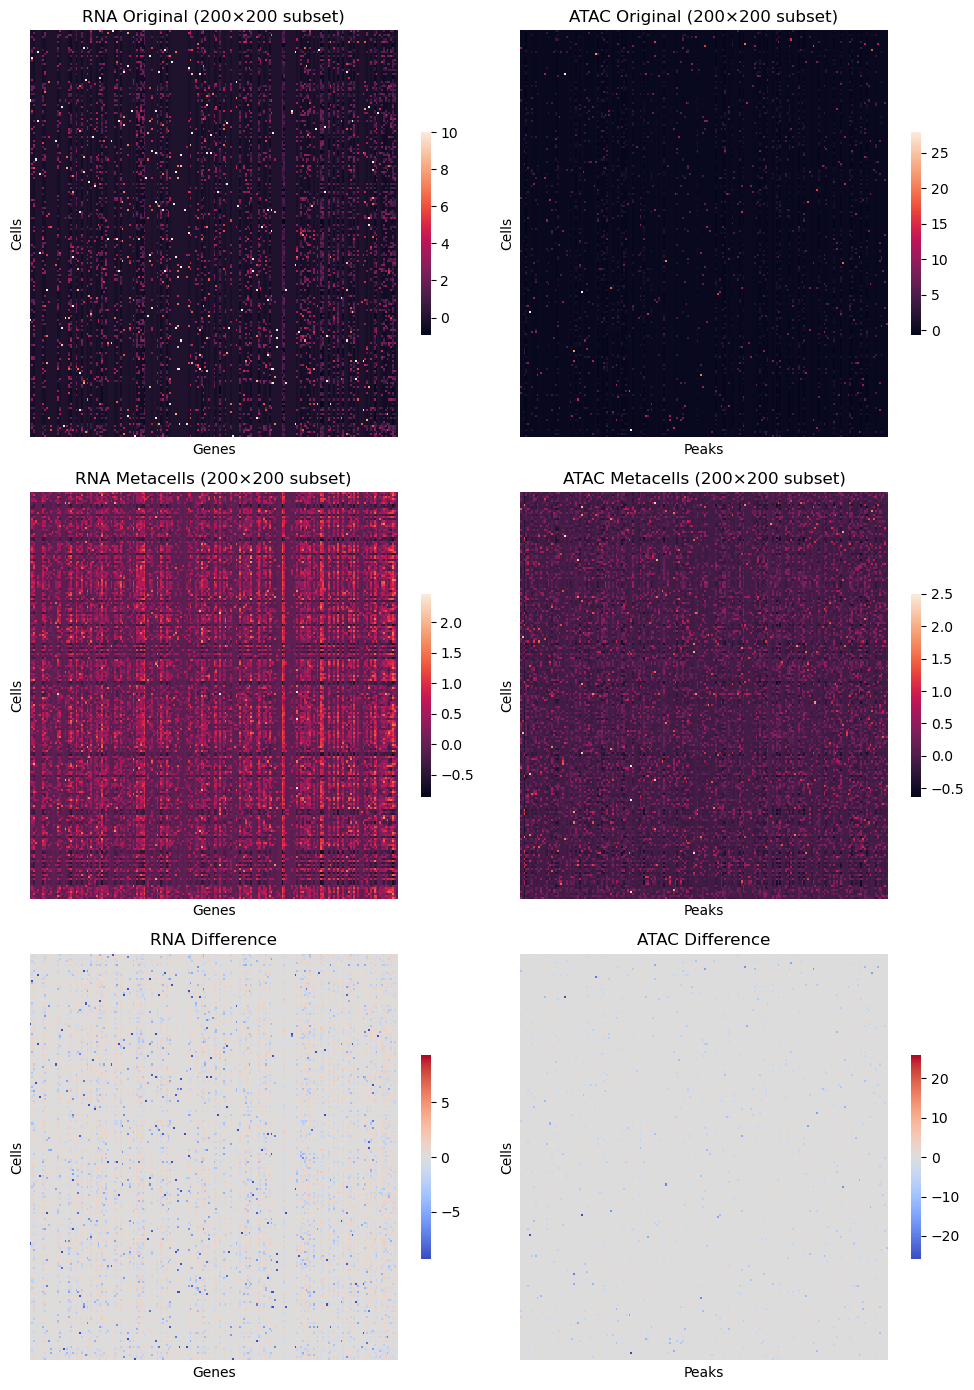

In [88]:
def to_dense_subset(X, n_cells=200, n_features=200):
    if sp.issparse(X):
        X = X[:n_cells, :n_features].toarray()
    else:
        X = np.asarray(X[:n_cells, :n_features])
    return X

# choose a subset
Xr_orig = to_dense_subset(X_rna, n_cells=200, n_features=200)
Xa_orig = to_dense_subset(X_atac, n_cells=200, n_features=200)   # fixed
Xr = to_dense_subset(X_rna_soft, n_cells=200, n_features=200)
Xa = to_dense_subset(X_atac_soft, n_cells=200, n_features=200)

# differences
Xr_diff = Xr - Xr_orig
Xa_diff = Xa - Xa_orig

Xr_absdiff = np.abs(Xr_diff)
Xa_absdiff = np.abs(Xa_diff)

fig, ax = plt.subplots(3, 2, figsize=(10, 14))

# originals
sns.heatmap(Xr_orig, ax=ax[0, 0], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[0, 0].set_title("RNA Original (200×200 subset)")
ax[0, 0].set_xlabel("Genes")
ax[0, 0].set_ylabel("Cells")

sns.heatmap(Xa_orig, ax=ax[0, 1], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[0, 1].set_title("ATAC Original (200×200 subset)")
ax[0, 1].set_xlabel("Peaks")
ax[0, 1].set_ylabel("Cells")

# weighted
sns.heatmap(Xr, ax=ax[1, 0], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[1, 0].set_title("RNA Metacells (200×200 subset)")
ax[1, 0].set_xlabel("Genes")
ax[1, 0].set_ylabel("Cells")

sns.heatmap(Xa, ax=ax[1, 1], xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.5})
ax[1, 1].set_title("ATAC Metacells (200×200 subset)")
ax[1, 1].set_xlabel("Peaks")
ax[1, 1].set_ylabel("Cells")

# signed differences
rna_lim = np.max(np.abs(Xr_diff))
atac_lim = np.max(np.abs(Xa_diff))

sns.heatmap(
    Xr_diff,
    ax=ax[2, 0],
    xticklabels=False,
    yticklabels=False,
    cmap="coolwarm",
    center=0,
    vmin=-rna_lim,
    vmax=rna_lim,
    cbar_kws={"shrink": 0.5}
)
ax[2, 0].set_title("RNA Difference")
ax[2, 0].set_xlabel("Genes")
ax[2, 0].set_ylabel("Cells")

sns.heatmap(
    Xa_diff,
    ax=ax[2, 1],
    xticklabels=False,
    yticklabels=False,
    cmap="coolwarm",
    center=0,
    vmin=-atac_lim,
    vmax=atac_lim,
    cbar_kws={"shrink": 0.5}
)
ax[2, 1].set_title("ATAC Difference")
ax[2, 1].set_xlabel("Peaks")
ax[2, 1].set_ylabel("Cells")

plt.tight_layout()
plt.show()

Show how the cells cluster by their expression and accessibility profiles before and after diffusion.

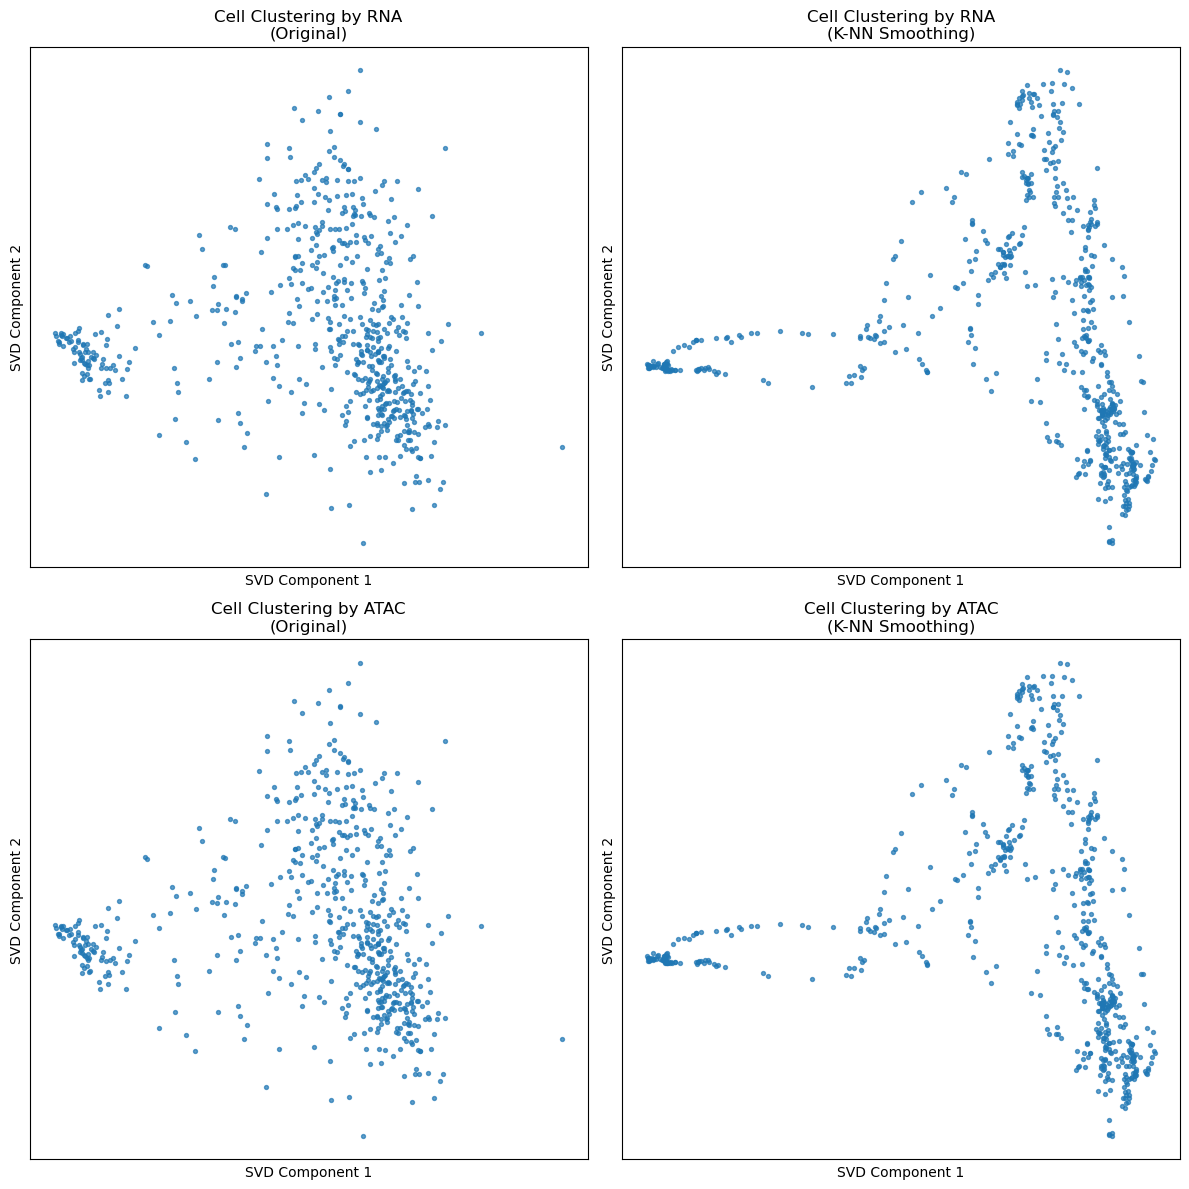

In [86]:
from sklearn.decomposition import TruncatedSVD
def fit_svd_2d(X, n_cells=1000, n_features=1000):
    if sp.issparse(X):
        Xsub = X[:n_cells, :n_features]
    else:
        Xsub = np.asarray(X[:n_cells, :n_features])
    svd = TruncatedSVD(n_components=2, random_state=0)
    coords = svd.fit_transform(Xsub)
    return coords

rna_orig_2d = fit_svd_2d(X_rna)
rna_soft_2d = fit_svd_2d(X_rna_soft)

atac_orig_2d = fit_svd_2d(X_atac)
atac_soft_2d = fit_svd_2d(X_atac_soft)

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

ax[0,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
ax[0,0].set_title("Cell Clustering by RNA\n(Original)")
ax[0,0].set_xlabel("SVD Component 1")
ax[0,0].set_ylabel("SVD Component 2")
ax[0,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[0,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
ax[0,1].set_title("Cell Clustering by RNA\n(K-NN Smoothing)")
ax[0,1].set_xlabel("SVD Component 1")
ax[0,1].set_ylabel("SVD Component 2")
ax[0,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[1,0].scatter(rna_orig_2d[:, 0], rna_orig_2d[:, 1], s=8, alpha=0.7)
ax[1,0].set_title("Cell Clustering by ATAC\n(Original)")
ax[1,0].set_xlabel("SVD Component 1")
ax[1,0].set_ylabel("SVD Component 2")
ax[1,0].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

ax[1,1].scatter(rna_soft_2d[:, 0], rna_soft_2d[:, 1], s=8, alpha=0.7)
ax[1,1].set_title("Cell Clustering by ATAC\n(K-NN Smoothing)")
ax[1,1].set_xlabel("SVD Component 1")
ax[1,1].set_ylabel("SVD Component 2")
ax[1,1].tick_params(axis='both', which='both', bottom=False, left=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.show()
## Create and save the pseudobulk DataFrames
def _standardize_symbols_index(
    df: pd.DataFrame,
    *,
    strip_version_suffix: bool = True,
    uppercase: bool = True,
    deduplicate: str = "sum",
) -> pd.DataFrame:
    x = df.copy()
    idx = x.index.astype(str).str.strip()
    if strip_version_suffix:
        idx = idx.str.replace(r"\.\d+$", "", regex=True)
    if uppercase:
        idx = idx.str.upper()
    x.index = idx
    if deduplicate:
        if deduplicate == "sum":
            x = x.groupby(level=0).sum()
        elif deduplicate == "mean":
            x = x.groupby(level=0).mean()
        elif deduplicate == "first":
            x = x[~x.index.duplicated(keep="first")]
        elif deduplicate in {"max", "min", "median"}:
            x = getattr(x.groupby(level=0), deduplicate)()
        else:
            raise ValueError(f"Unknown deduplicate policy: {deduplicate}")
    return x

pseudo_bulk_rna_df = pd.DataFrame(
    X_rna_soft.T.toarray(),
    index=mdata["rna"].var_names,
    columns=mdata["rna"].obs_names,
).fillna(0)

pseudo_bulk_atac_df = pd.DataFrame(
    X_atac_soft.T.toarray(),
    index=mdata["atac"].var_names,
    columns=mdata["atac"].obs_names,
).fillna(0)

pseudo_bulk_rna_df = _standardize_symbols_index(pseudo_bulk_rna_df)
pseudobulk_rna_file = SAMPLE_PROCESSED_DATA_DIR / "TG_pseudobulk.parquet"
pseudobulk_atac_file = SAMPLE_PROCESSED_DATA_DIR / "RE_pseudobulk.parquet"

pseudo_bulk_rna_df.to_parquet(pseudobulk_rna_file, engine="pyarrow", compression="snappy")
pseudo_bulk_atac_df.to_parquet(pseudobulk_atac_file, engine="pyarrow", compression="snappy")
    

In [89]:
pseudo_bulk_rna_df.head()

print(f"Num Genes: {pseudo_bulk_rna_df.shape[0]}")
print(f"Num Peaks: {pseudo_bulk_atac_df.shape[0]}")
print(f"Num Metacells: {pseudo_bulk_rna_df.shape[1]}")

Num Genes: 28385
Num Peaks: 170825
Num Metacells: 621
